# Using Gambit with SageMath: strategic form games

[SageMath](https://www.sagemath.org/) is a general-purpose open-source mathematics system built on top of Python.
Its `sage.game_theory` module inclludes a `NormalFormGame` class, which integrates Gambit solvers.

This tutorial shows how a game can be created and analyzed by the two libraries, walks through each part of the interface, and finishes with two case studies that use SageMath to do things Gambit cannot do on its own: solving a game whose payoffs are *symbols* rather than numbers, and building a game out of a combinatorial object.

The clear benefit of using both libraries is their combined expertise:

- **Gambit** knows how to compute equilibria. Its solvers are fast, numerous, and established.
- **SageMath** knows how to do mathematics *around* the game: exact rational and symbolic algebra, graphs and other combinatorial structures, plotting, and calculus.

> **Requirements.** This tutorial uses the SageMath interface introduced in [sagemath/sage#42367](https://github.com/sagemath/sage/pull/42367), which at the time of writing has not yet been released.
> You will need a SageMath build containing that work, plus the optional `pygambit` package (`sage --pip install pygambit`).
> Run the notebook with the **SageMath kernel**, not a plain Python kernel: the examples below rely on Sage's preparser, which makes `1/3` an exact rational rather than a floating point number.

In [1]:
import itertools

import numpy as np
from sage.version import version

import pygambit as gbt

print("SageMath", version, "| pygambit", gbt.__version__)

SageMath 10.10.beta6 | pygambit 16.7.0


## From a Gambit game to a Sage game

We start on the Gambit side, with the Prisoner's Dilemma built from a pair of payoff arrays.

In [2]:
pd_gambit = gbt.Game.from_arrays(
    np.array([[3, 0], [5, 1]]),
    np.array([[3, 5], [0, 1]]),
    title="Prisoner's Dilemma",
)
pd_gambit

Game(title='Prisoner's Dilemma')

Passing that `Game` straight to `NormalFormGame` converts it.
A Sage normal form game is a mapping from strategy profiles (tuples of integers) to lists of payoffs, so this is what we get back:

In [3]:
pd = NormalFormGame(pd_gambit)
pd

Normal Form Game with the following utilities: {(0, 0): [3, 3], (0, 1): [0, 5], (1, 0): [5, 0], (1, 1): [1, 1]}

Notice what happened to the numbers.
Gambit stores payoffs either as exact rationals or as decimals, and Sage keeps that distinction: the integer payoffs above came back as elements of `QQ`, the field of rational numbers, and *not* as floating point approximations.

In [4]:
parent(pd.utilities[(0, 0)][0])

Rational Field

That matters for everything downstream. `payoff_matrices` hands us the two payoff matrices as genuine Sage matrices over `QQ`, which we can then do linear algebra on.

In [5]:
A, B = pd.payoff_matrices()
A, B, A.base_ring()

(
[3 0]  [3 5]                
[5 1], [0 1], Rational Field
)

## From a Sage game to a Gambit game

The other direction is the `_gambit_` method, which every Sage object that knows how to talk to Gambit provides.
It returns a `pygambit.Game`, so the whole Gambit API is available from there — including writing the game out in Gambit's own strategic form format.

In [6]:
print(pd._gambit_().to_nfg())

NFG 1 R "Untitled strategic game" { "1" "2" }

{ { "1" "2" }
{ "1" "2" }
}
""

{
{ "" 3.0, 3.0 }
{ "" 5.0, 0.0 }
{ "" 0.0, 5.0 }
{ "" 1.0, 1.0 }
}
1 2 3 4 



Two options are worth knowing about:

- `as_integer=True` truncates every payoff to an integer, which is useful when a solver benefits from exact integer arithmetic.
- `maximization=False` negates every payoff, so a game written down in terms of *costs* is handed to Gambit as a game to be maximised.

In [7]:
g_float = pd._gambit_()
g_int = pd._gambit_(as_integer=True)
g_min = pd._gambit_(maximization=False)

[float(g_float["1", "1"][g_float.players["1"]]),
 int(g_int["1", "1"][g_int.players["1"]]),
 float(g_min["1", "1"][g_min.players["1"]])]

[3.0, 3, -3.0]

## Saving and loading games

Because the conversion goes through Gambit, Sage can read and write Gambit's `.nfg` files directly.
This is the simplest way to move a game between a Sage session and the Gambit GUI, or to keep a game under version control.

In [8]:
path = tmp_filename(ext=".nfg")
pd.save_nfg(path)

reloaded = NormalFormGame()
reloaded.load_nfg(path)
reloaded

Normal Form Game with the following utilities: {(0, 0): [3.0, 3.0], (0, 1): [0.0, 5.0], (1, 0): [5.0, 0.0], (1, 1): [1.0, 1.0]}

One caveat: a `.nfg` file records payoffs as decimals, so a round trip through disk turns exact rationals into floating point numbers.
If you care about exactness, keep the Sage object and convert on demand rather than saving and reloading.

In [9]:
parent(reloaded.utilities[(0, 0)][0])

<class 'float'>

## The Gambit game catalog

Gambit ships a catalog of games from the research literature, and Sage can pull any of them in.
Called with no arguments, `load_from_gambit_catalog` returns a table of what is available.

In [10]:
catalog = NormalFormGame().load_from_gambit_catalog()
catalog

,Game,Title
0,books/myerson1991/fig2_1,A simple Poker game
1,books/myerson1991/fig4_2,Myerson (1991) Figure 4.2
2,books/shohamleytonbrown2008/fig5_1,Fig 5.1 from Shoham and Leyton-Brown (2008)
3,books/shohamleytonbrown2008/fig5_10,Fig 5.10 from Shoham and Leyton-Brown (2008)
4,books/shohamleytonbrown2008/fig5_11,Fig 5.11 from Shoham and Leyton-Brown (2008)
5,books/shohamleytonbrown2008/fig5_12,Fig 5.12 from Shoham and Leyton-Brown (2008)
6,books/shohamleytonbrown2008/fig5_15,Fig 5.15 from Shoham and Leyton-Brown (2008)
7,books/shohamleytonbrown2008/fig5_2,Fig 5.2 from Shoham and Leyton-Brown (2008)
8,books/shohamleytonbrown2008/fig5_9,Fig 5.9 from Shoham and Leyton-Brown (2008)
9,books/shohamleytonbrown2008/fig6_2,Fig 6.2 from Shoham and Leyton-Brown (2008)


Passing a name from the `Game` column loads that game.
Here is Bagwell's game on commitment and observability:

In [11]:
bagwell = NormalFormGame()
bagwell.load_from_gambit_catalog("journals/geb/bagwell1995", info=False)
bagwell

Normal Form Game with the following utilities: {(0, 0): [5, 2],
 (0, 1): [249/50, 199/100],
 (0, 2): [151/50, 101/100],
 (0, 3): [3, 1],
 (1, 0): [6, 3],
 (1, 1): [201/50, 399/100],
 (1, 2): [299/50, 301/100],
 (1, 3): [4, 4]}

## Solving games

`obtain_nash` is Sage's entry point to equilibrium computation.
Without an algorithm it picks a sensible default; with one, it dispatches either to Sage's own exact routines or to one of Gambit's solvers.

Our test case is the Battle of the Sexes, which has two pure equilibria and one mixed one.

In [12]:
battle = NormalFormGame([matrix([[3, 1], [0, 2]]),
                         matrix([[2, 1], [0, 3]])])
battle.obtain_nash()

[[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]

The default answer is *exact*: the mixed equilibrium comes out as `3/4` and `1/2`, not as decimals.
That is Sage's own vertex enumeration at work.

Handing the same game to Gambit's solvers gives the same equilibria as floating point approximations.
`'enumeration'` stays in Sage, while `'LCP'` and `'enummixed'` are Gambit's.
(Sage also offers `'lrs'`, which uses the external `lrslib` package; it is not installed here, so it is left out of the comparison below.)

In [13]:
for algorithm in ["enumeration", "LCP", "enummixed"]:
    print(f"{algorithm:12s}", battle.obtain_nash(algorithm=algorithm))

enumeration  [[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]
LCP          [[(0.0, 1.0), (0.0, 1.0)], [(0.7499999999999999, 0.25), (0.24999999999999994, 0.7500000000000001)], [(1.0, 0.0), (1.0, 0.0)]]
enummixed    [[(0.0, 1.0), (0.0, 1.0)], [(0.7499999999999999, 0.25), (0.24999999999999994, 0.7500000000000001)], [(1.0, 0.0), (1.0, 0.0)]]


So the two libraries are complementary here too: use Sage's solvers when you want exact answers on a small game, and Gambit's when the game is large enough that exact arithmetic becomes the bottleneck.

Sage can also tell you whether the game is degenerate, which is worth checking before trusting an equilibrium count.

In [14]:
battle.is_degenerate()

False

## Games with more than two players

A two player game is a pair of matrices, but a game with $n$ players needs $n$ payoff arrays of $n$ dimensions each, and a Sage matrix is only ever two dimensional.
For more than two players, pass NumPy arrays instead.

Here is a three player consensus game: everybody picks one of two options, and everybody scores a point only if all three agree.

In [15]:
agree = np.zeros((2, 2, 2), dtype=int)
agree[0, 0, 0] = 1
agree[1, 1, 1] = 1

consensus = NormalFormGame([agree, agree, agree])
consensus.obtain_nash(algorithm="enumpure")

[[(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)], [(1.0, 0.0), (1.0, 0.0), (1.0, 0.0)]]

Both "everyone picks the first option" and "everyone picks the second" are equilibria, as expected.

This is where Gambit really earns its place: Sage's own solvers only handle two players, so every algorithm for larger games — `'gnm'`, `'enumpure'`, `'enumpoly'`, `'liap'`, `'simpdiv'`, `'ipa'` and `'logit'` — is Gambit's.
The default for a game with more than two players is `'enumpoly'`, which finds the mixed equilibrium too.

In [16]:
consensus.obtain_nash()

[[(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)],
 [(0.5, 0.5), (0.5, 0.5), (0.5, 0.5)],
 [(1.0, 0.0), (1.0, 0.0), (1.0, 0.0)]]

## Plotting a game

Sage can draw a two player game as a labelled payoff bimatrix, optionally marking each player's best responses and the pure equilibria.

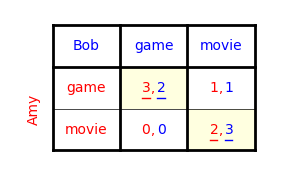

In [17]:
battle.plot(player_labels=["Amy", "Bob"],
            strategy_labels=[["game", "movie"], ["game", "movie"]],
            best_responses=True, pure_nash=True)

## Case study 1: a game whose payoffs are symbols

Everything so far could be described as file conversion. This is where the integration starts to pay for itself.

Gambit's solvers work on numbers. Sage's symbolic ring works on *expressions*, and a `NormalFormGame` is perfectly happy to hold them. So we can write down a whole family of games at once and solve it in closed form.

The example is Hawk–Dove. Two animals contest a resource worth $v$. Two doves split it; a hawk takes it from a dove; two hawks fight and share the value minus a cost $c$ of injury.

In [18]:
v, c, p = var("v c p")

H = matrix([[(v - c)/2, v],
            [0,         v/2]])
hawk_dove = NormalFormGame([H, H.transpose()])
hawk_dove

Normal Form Game with the following utilities: {(0, 0): [-1/2*c + 1/2*v, -1/2*c + 1/2*v],
 (0, 1): [v, 0],
 (1, 0): [0, v],
 (1, 1): [1/2*v, 1/2*v]}

In the mixed equilibrium each animal plays Hawk with some probability $p$ that leaves its opponent indifferent between the two behaviours.
We write that indifference condition down and ask Sage to solve it.

In [19]:
hawk = p*(v - c)/2 + (1 - p)*v
dove = (1 - p)*v/2

solution = solve(hawk == dove, p)
solution

[p == v/c]

The equilibrium share of hawks is $p^* = v/c$ — a closed form valid for every $v$ and $c$ at once, which no numerical solver could have produced.
Being an ordinary Sage expression, we can now plot it, differentiate it, or take limits of it.

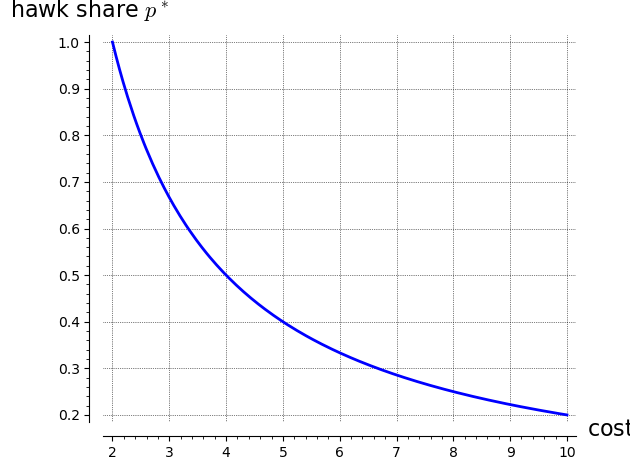

In [20]:
p_star = solution[0].rhs()

plot(p_star.subs(v=2), (c, 2, 10), axes_labels=["cost $c$", "hawk share $p^*$"],
     thickness=2, gridlines=True)

And we can check the formula against Gambit.
Substituting $v = 2$, $c = 5$ turns the symbolic matrices into numeric ones, at which point the game converts and Gambit's `enummixed` solver applies.

In [21]:
numeric = NormalFormGame([H.subs(v=2, c=5),
                          H.transpose().subs(v=2, c=5)])
numeric.obtain_nash(algorithm="enummixed")

[[(0.0, 1.0), (1.0, 0.0)],
 [(0.39999999999999997, 0.6000000000000001),
  (0.39999999999999997, 0.6000000000000001)],
 [(1.0, 0.0), (0.0, 1.0)]]

The middle equilibrium puts weight `0.39999999999999997` on Hawk. That is Gambit's floating point rendering of a number the formula gives us exactly:

In [22]:
p_star.subs(v=2, c=5)

2/5

## Case study 2: from a graph to a game

The second thing Sage brings is its library of mathematical objects. Here we turn a *graph* into a game and let Gambit analyse it.

In the **max cut game**, every vertex of a graph is a player choosing one of two sides. A player's payoff is the number of its incident edges that end up cut, that is, joining vertices on opposite sides. A pure Nash equilibrium is exactly a cut that no single vertex can improve by switching sides — a *locally* optimal cut.

We use the house graph: five vertices, six edges.

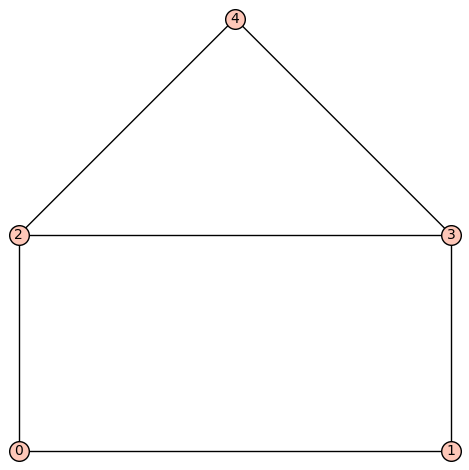

In [23]:
G = graphs.HouseGraph()
G.plot(vertex_labels=True)

Building the game is a matter of filling in one payoff array per vertex.
Sage's graph API supplies the vertices and the neighbours, and NumPy holds the payoffs.

In [24]:
def max_cut_game(graph):
    """Return the max cut game of ``graph`` as a Sage ``NormalFormGame``."""
    vertices = sorted(graph.vertices())
    arrays = [np.zeros((2,) * len(vertices), dtype=int) for _ in vertices]
    for profile in itertools.product([0, 1], repeat=len(vertices)):
        side = dict(zip(vertices, profile, strict=True))
        for i, u in enumerate(vertices):
            arrays[i][profile] = sum(1 for w in graph.neighbors(u)
                                     if side[w] != side[u])
    return NormalFormGame(arrays)


game = max_cut_game(G)
len(game.players)

5

Five players, so this is squarely in Gambit's territory. `'enumpure'` enumerates the pure equilibria.

In [25]:
equilibria = game.obtain_nash(algorithm="enumpure")
len(equilibria)

6

Now we read each equilibrium back as a cut and measure it — and here Sage answers a question Gambit cannot even be asked, by computing the true maximum cut exactly.

In [26]:
def cut_size(profile):
    return sum(1 for (u, w) in G.edges(labels=False) if profile[u] != profile[w])


profiles = sorted({tuple(int(round(s[1])) for s in eq) for eq in equilibria})
table([(profile, cut_size(profile)) for profile in profiles],
      header_row=["equilibrium", "edges cut"])

equilibrium,edges cut
"\(\left(0, 0, 1, 1, 0\right)\)",\(4\)
"\(\left(0, 1, 1, 0, 0\right)\)",\(5\)
"\(\left(0, 1, 1, 0, 1\right)\)",\(5\)
"\(\left(1, 0, 0, 1, 0\right)\)",\(5\)
"\(\left(1, 0, 0, 1, 1\right)\)",\(5\)
"\(\left(1, 1, 0, 0, 1\right)\)",\(4\)


In [27]:
G.max_cut(value_only=True)

5

Four of the six equilibria achieve the optimum of five cut edges, but two of them get stuck at four.
Those are the locally stable cuts that are not globally optimal, and the ratio $4/5$ is this game's price of anarchy.

Gambit found the equilibria; Sage certified which of them were actually good. Neither library could have produced that sentence alone.

## Summary

| Task | Call |
|---|---|
| Gambit game to Sage | `NormalFormGame(game)` |
| Sage game to Gambit | `game._gambit_()` |
| Read and write `.nfg` | `game.load_nfg(path)`, `game.save_nfg(path)` |
| Browse and load catalog games | `game.load_from_gambit_catalog()` |
| Solve with Sage (exact, two players) | `game.obtain_nash(algorithm='enumeration')` |
| Solve with Gambit | `game.obtain_nash(algorithm='LCP')` and friends |
| Solve with more than two players | `game.obtain_nash(algorithm='enumpoly')` |
| Draw the payoff bimatrix | `game.plot()` |

For games in extensive form — trees, information sets, and chance moves — see the companion tutorial, [Using Gambit with SageMath: extensive form games](sagemath_extensive_form.ipynb).

Further reading:

- [SageMath game theory reference](https://doc.sagemath.org/html/en/reference/game_theory/index.html)
- [PyGambit API documentation](https://gambitproject.readthedocs.io/en/latest/pygambit.api.html)